# Traitement de l'EUEMr
Ce Notebook qui permet générer le réseau baysien basé sur les données de l'EUEMr

## Table des matières
- [Formatage de l'EUEMr](#PreTraitement)
- [Création du BN](#Creation)
- [Test](#Test)

In [1]:
"""
Created on 26-06-2025

@author: cv1751 - Brice Le Lostec
@description: Class for generating Bayesian Networks (BN) using pyAgrum.
@note: This class provides methods to save, load, plot Bayesian Networks and load CSV files.
@version: 1.0
python 3.11

"""
import numpy as np
import pandas as pd
import sys
import os
import yaml

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.Master_genereBN import Master_genereBN
from EUEMr import FormatageEUEMr, EUEMr

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# PreTraitement
Creer un fichier csv formaté avec les colonnes d'intérêt de l'EUEMr, lesquelles sont transformées

In [2]:
# Creer un fichier csv formaté avec les colonnes d'intérêt
InsClsSondage = FormatageEUEMr()
InsClsSondage.Main()
#InsClsSondage.get_Mettadata()


DataFrame saved to n:\Mes Documents\Projets LTE\Projet archQc\code\GITHUB_Repo\LTE-Sampler-Residential//data//EUEMr//2022//sondage_residentiel_version_finale_formatted.csv.


# Création
Création d'un réseau bayesien

In [3]:
import pyagrum as gum
gum.availableBNExts()

'bif|dsl|net|bifxml|o3prm|uai|xdsl|pkl'

In [4]:
#import pyagrum
#gum.availableBNExts()

InsClsEUEMr = EUEMr()
InsClsEUEMr.Make_csv()
InsClsEUEMr.Make_BN()

path = "../data/BayesianNetwork/BN_EUEMr.XDSL"
InsClsEUEMr.Save_BN(path)

#save Structure

with open("../dataStructure/Bn.yml", 'w') as outfile:
    yaml.dump([InsClsEUEMr.NOEUD_EUEMr, InsClsEUEMr.LIST_Dict], outfile, default_flow_style=False)




In [5]:
with open("../dataStructure/Bn.yml", 'r') as file:
        a,b = yaml.safe_load(file)
b

{'An_Construction': {'0': '< 1950',
  '1': '[1950 - 1960)',
  '2': '[1960 - 1970)',
  '3': '[1970 - 1980)',
  '4': '[1980 - 1990)',
  '5': '[1990 - 2000)',
  '6': '[2000 - 2010)',
  '7': '[2010 - 2020)',
  '8': '>= 2020'},
 'Chauffage_Logement': {'0': 'Plinthes électriques',
  '1': 'Unités convecteurs, plancher ou plafond radiant',
  '10': 'Fournaise ou poêle à bois et Système central à air chaud',
  '11': 'Fournaise ou poêle à bois et Système central à eau chaude',
  '12': 'Fournaise ou poêle à bois et Fournaise murale ou de plancher',
  '2': 'Thermopompe',
  '3': 'Système central à air chaud',
  '4': 'Système central à eau chaude',
  '5': 'Fournaise ou poêle à bois',
  '6': 'Fournaise murale ou de plancher',
  '7': 'Fournaise ou poêle à bois et Plinthes électriques',
  '8': 'Fournaise ou poêle à bois et Unités convecteurs, plancher ou plafond radiant',
  '9': 'Fournaise ou poêle à bois et Thermopompe'},
 'Climatisation': {'0': 'Aucune',
  '1': 'Fenêtre, mobile, portable',
  '2': 'Mur

# Test
Test du réseau bayesien créé

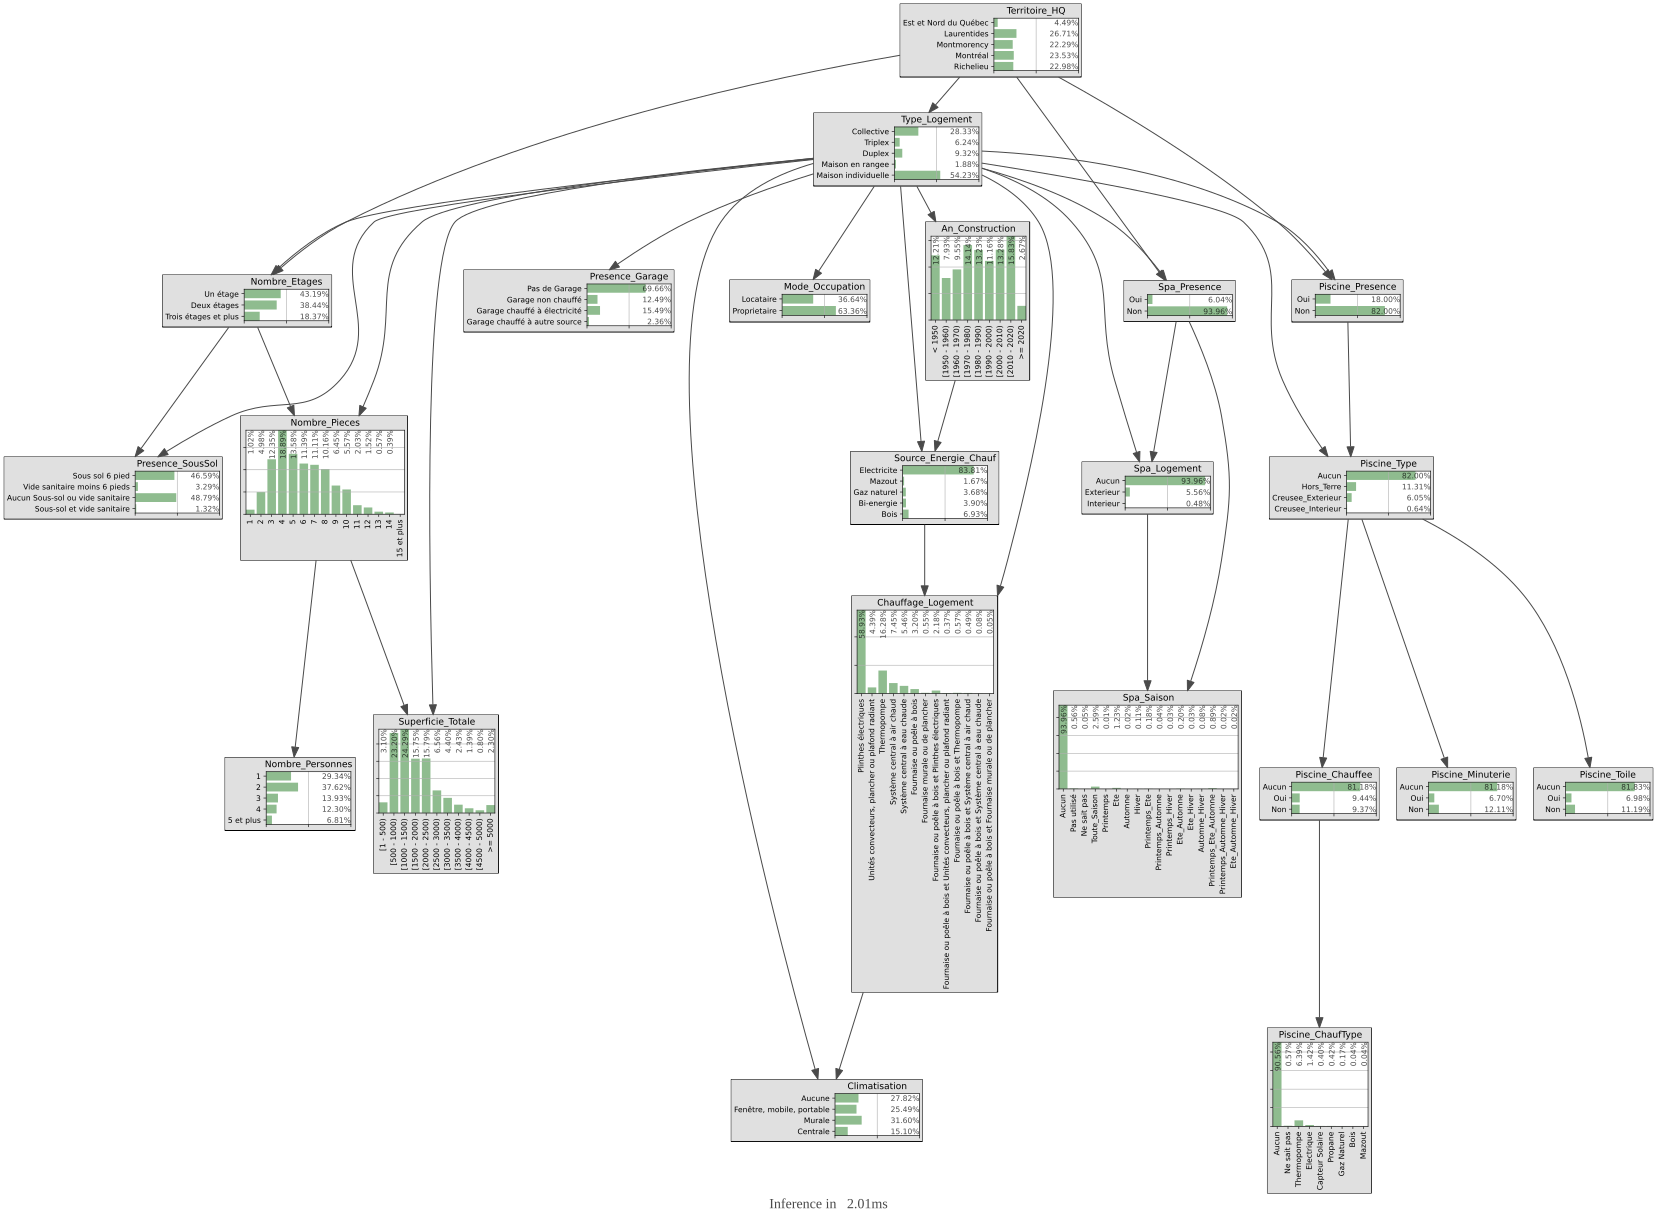

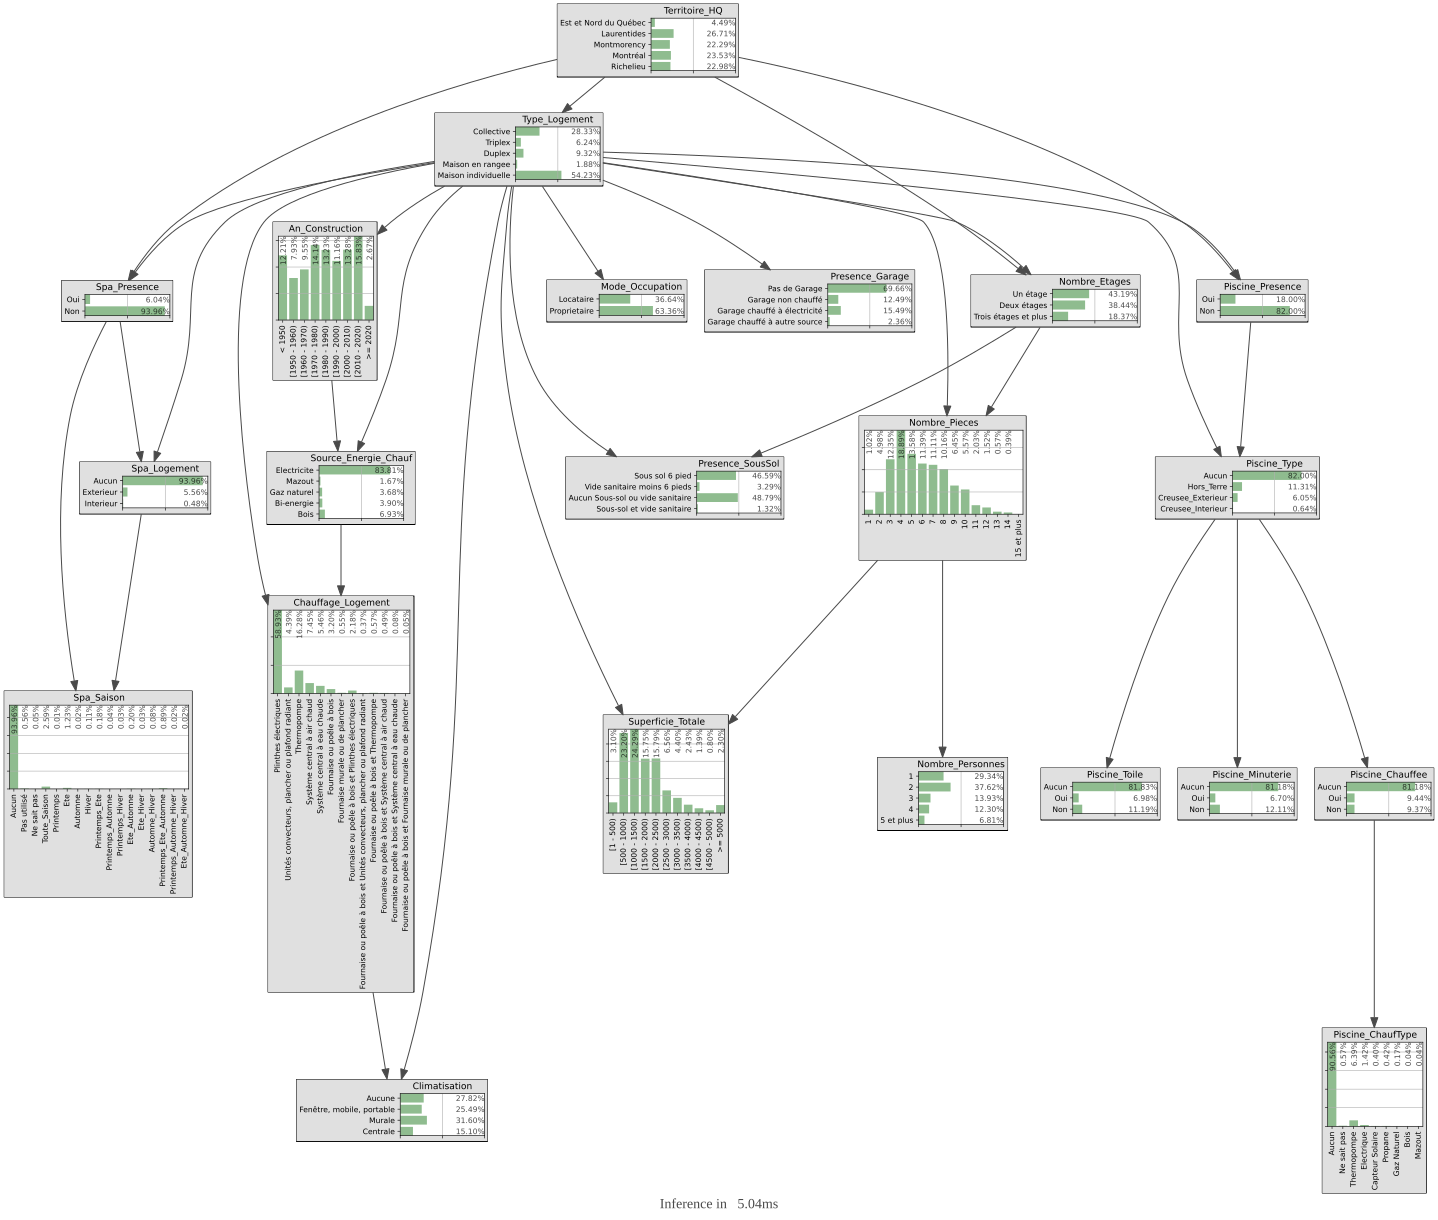

In [6]:
import pyagrum as gum
#import pyagrum.lib.ipython as gnb
import pyagrum.lib.notebook as gnb

# Load the Bayesian Network from the saved file
InsClsEUEMr_2 = EUEMr()
path = parent_dir+"/data/BayesianNetwork/BN_EUEMr.XDSL"
InsClsEUEMr_2.Load_BN(path)

# Display the Bayesian Network - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn,evs={},size = '30')

# Display the Bayesian Network - Apres enregistrement
gnb.showInference(InsClsEUEMr_2.bn,evs={},size = '30')

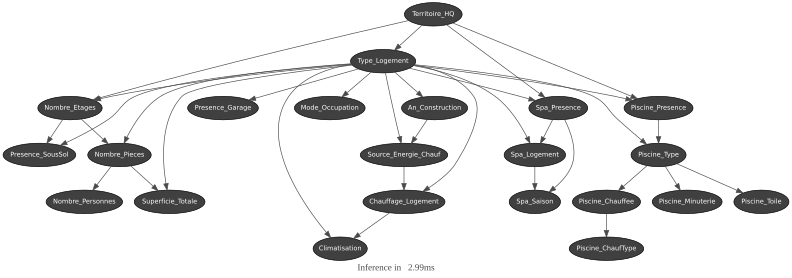

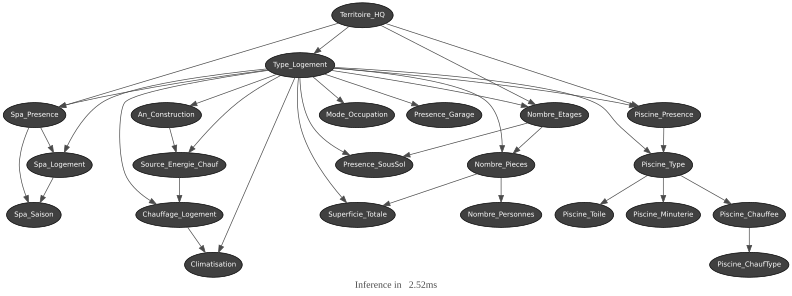

In [7]:
# Display the Bayesian Network - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn, evs={}, targets={"AnConstruction"}, size="11")

# Display the Bayesian Network - Apres enregistrement
gnb.showInference(InsClsEUEMr_2.bn, evs={}, targets={"AnConstruction"}, size="11")


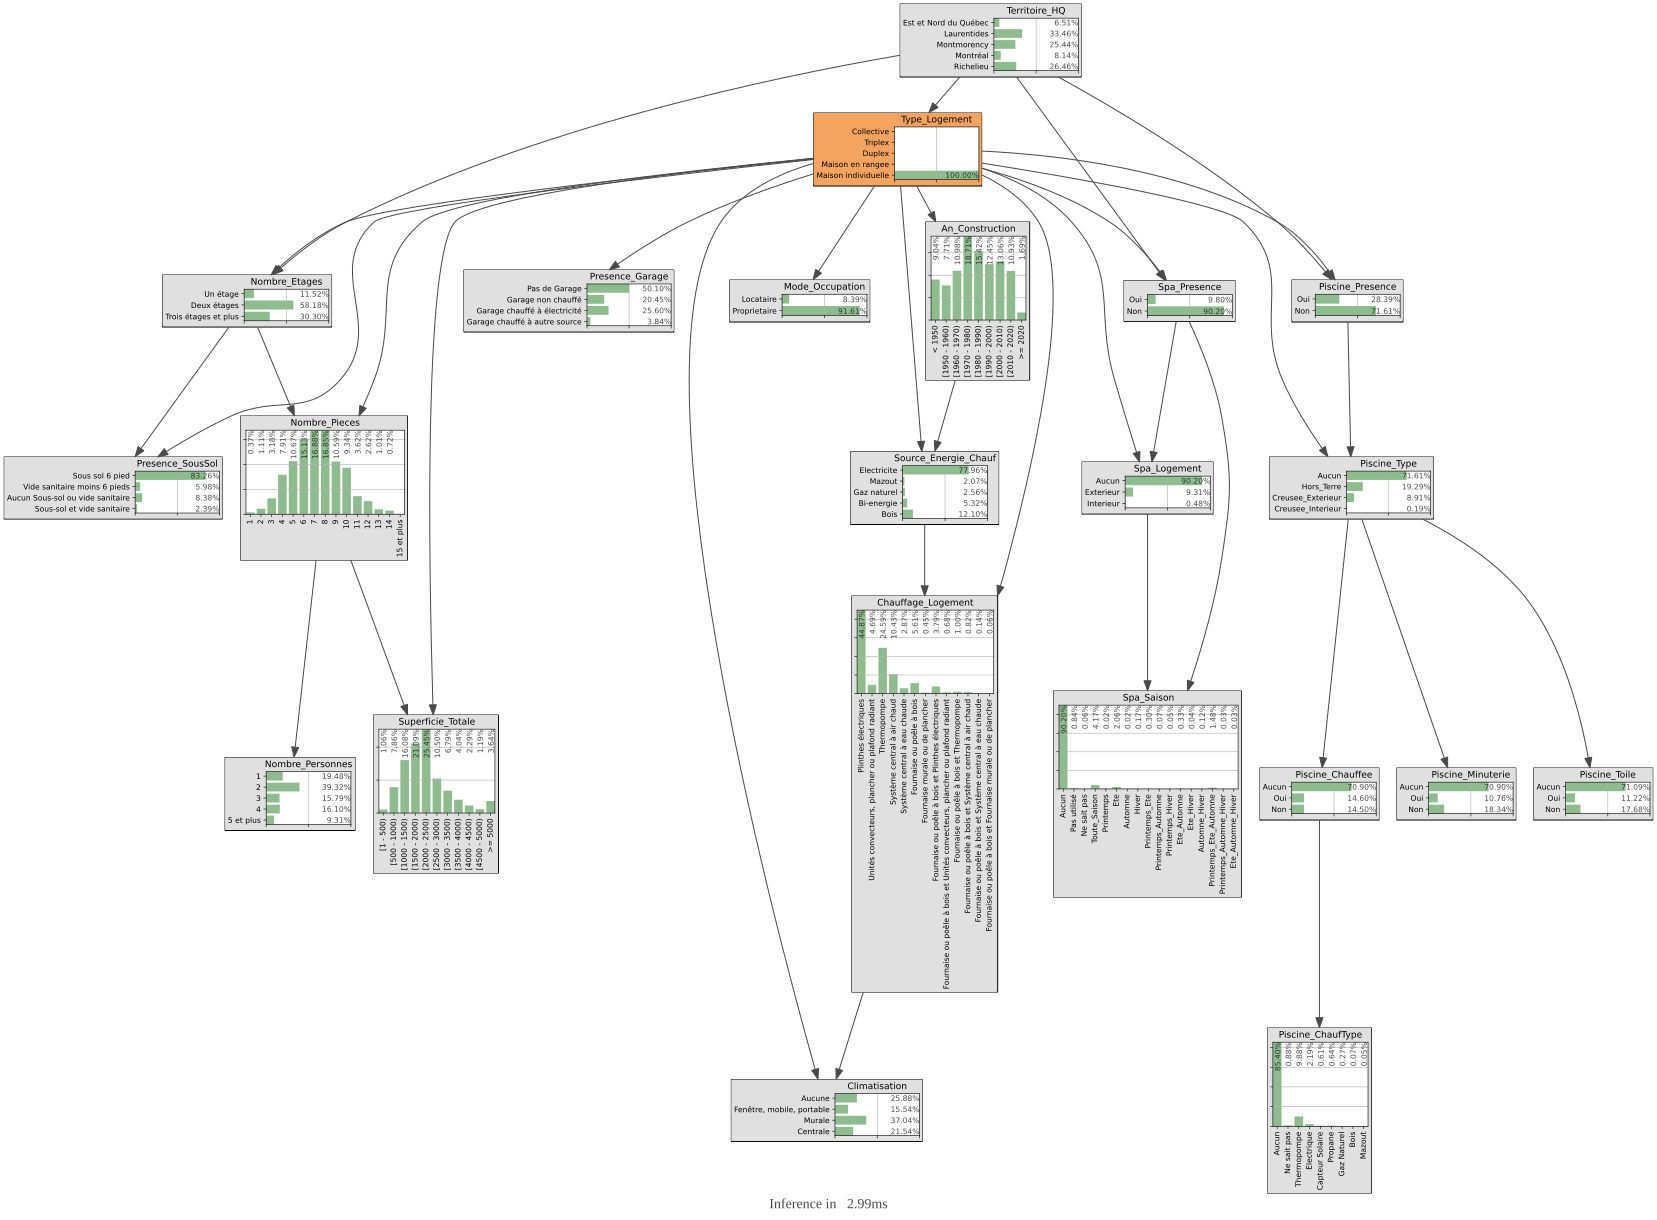

In [8]:
# Display the Bayesian Network with specific evidence - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn,evs={"Type_Logement": "Maison individuelle"},size = '30')

# Display the Bayesian Network with specific evidence - Apres enregistrement
#gnb.showInference(InsClsEUEMr_2.bn,evs={"Mode_Occupation": "Proprietaire"},size = '30')


In [9]:
Nombre_de_Samples = 3
Evidence = {"Mode_Occupation": "Proprietaire"}

# Fait un échantillonage - Avant enregistrement
df1 = InsClsEUEMr.do_Sampling(Nombre_de_Samples, evs = Evidence)

# Fait un échantillonage - Apres enregistrement
df2 = InsClsEUEMr_2.do_Sampling(Nombre_de_Samples, evs = Evidence)

# Affiche les échantillons - Avant enregistrement
df1, df2

(  Territoire_HQ        Type_Logement Spa_Presence Spa_Logement Spa_Saison  \
 0      Montréal               Duplex          Non        Aucun      Aucun   
 1   Laurentides  Maison individuelle          Non        Aucun      Aucun   
 2      Montréal  Maison individuelle          Non        Aucun      Aucun   
 
       Presence_Garage An_Construction Source_Energie_Chauf  \
 0  Garage non chauffé   [2010 - 2020)          Electricite   
 1       Pas de Garage   [1970 - 1980)          Electricite   
 2       Pas de Garage   [2000 - 2010)          Electricite   
 
                                 Chauffage_Logement Climatisation  ...  \
 0                             Plinthes électriques        Aucune  ...   
 1  Unités convecteurs, plancher ou plafond radiant        Aucune  ...   
 2                             Plinthes électriques        Murale  ...   
 
   Nombre_Pieces Superficie_Totale Nombre_Personnes Piscine_Presence  \
 0             5     [1000 - 1500)                4           

In [10]:
#proportion de valeur
# Fait un échantillonage - Apres enregistrement
df3 = InsClsEUEMr_2.do_Sampling(1000, evs = {})

for col in df2.columns:
    print(col + ":" + str(df3[col].value_counts()/ len(df3)))


Territoire_HQ:Territoire_HQ
Laurentides              0.257
Montréal                 0.239
Montmorency              0.231
Richelieu                0.227
Est et Nord du Québec    0.046
Name: count, dtype: float64
Type_Logement:Type_Logement
Maison individuelle    0.531
Collective             0.287
Duplex                 0.087
Triplex                0.079
Maison en rangee       0.016
Name: count, dtype: float64
Presence_Garage:Presence_Garage
Pas de Garage                    0.701
Garage chauffé à électricité     0.151
Garage non chauffé               0.127
Garage chauffé à autre source    0.021
Name: count, dtype: float64
Spa_Presence:Spa_Presence
Non    0.941
Oui    0.059
Name: count, dtype: float64
Spa_Logement:Spa_Logement
Aucun        0.941
Exterieur    0.056
Interieur    0.003
Name: count, dtype: float64
Spa_Saison:Spa_Saison
Aucun                      0.941
Toute_Saison               0.021
Ete                        0.016
Printemps_Ete_Automne      0.010
Pas utilisé                